# Dataset Report — `tomato_ripeness_v1`

Notebook chỉ **đọc** (không build lại) Kaggle Dataset đã được `01_build_tomato_ripeness_v1.ipynb` sinh ra, để xác nhận nhanh bộ dữ liệu cuối cùng trước khi dùng cho training.

## Trước khi chạy
1. **Add Input** → chọn Kaggle Dataset output của `01_build_tomato_ripeness_v1.ipynb` (dataset đã bấm **Save Version → Save & Run All (Commit)** thành công — nếu chưa Save Version thì chưa có dataset nào để attach).
2. Không cần Internet, không cần GPU/Accelerator.

## Notebook này làm gì
1. Tự tìm `data.yaml` khớp đúng 3 class của `tomato_ripeness_v1` trong `/kaggle/input` (không đoán đường dẫn).
2. Thống kê số ảnh / số label / số box theo class cho từng split (`train`, `val`, `test`, `test_outdomain_openfield`) + dung lượng đĩa — tính trực tiếp từ file thật.
3. Thống kê kích thước ảnh (min/max/mean width-height, lấy mẫu ngẫu nhiên).
4. Vẽ biểu đồ phân bố class theo split.
5. Hiển thị ảnh ví dụ kèm bounding box cho từng split.
6. In lại `dataset_report.md` / `licenses.md` gốc (nếu có trong input) để có báo cáo đầy đủ ở một chỗ.

> Lưu ý: notebook này vẽ nhiều ảnh mẫu (`plt.show()`) nên file `.ipynb` sau khi chạy sẽ lớn hơn do nhúng ảnh base64 vào output. Nếu sau này import notebook này qua GitHub mà bị lỗi "Failed to fetch this content", xóa output các cell trước khi push (đã từng gặp lỗi tương tự ở `01_build_tomato_ripeness_v1.ipynb` do vượt giới hạn ~1MB của GitHub Contents API).

In [1]:
import random
from collections import defaultdict
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from PIL import Image

random.seed(42)
np.random.seed(42)

TARGET_CLASSES = ["fruit_green_unripe", "fruit_turning", "fruit_ripe"]
SPLITS = ["train", "val", "test", "test_outdomain_openfield"]


def find_dataset_root():
    """Tìm thư mục chứa data.yaml của tomato_ripeness_v1 (khớp đúng 3 class, không đoán đường dẫn)."""
    for yf in Path("/kaggle/input").rglob("data.yaml"):
        try:
            y = yaml.safe_load(yf.read_text(encoding="utf-8"))
        except Exception:
            continue
        names = y.get("names") if isinstance(y, dict) else None
        if isinstance(names, dict):
            names = [names[k] for k in sorted(names)]
        if names == TARGET_CLASSES:
            return yf.parent
    return None


def find_manifest_root():
    """Tìm thư mục manifests (chứa class_distribution.csv) sinh ra bởi 01_build_tomato_ripeness_v1.ipynb."""
    hits = list(Path("/kaggle/input").rglob("class_distribution.csv"))
    return hits[0].parent if hits else None


DATASET_ROOT = find_dataset_root()
MANIFEST_ROOT = find_manifest_root()

if DATASET_ROOT is None:
    print("Các thư mục cấp 1 trong /kaggle/input:")
    for p in sorted(Path("/kaggle/input").glob("*")):
        print(" -", p)
    raise FileNotFoundError(
        "Không tìm thấy data.yaml khớp 3 class của tomato_ripeness_v1 trong /kaggle/input.\n"
        "Kiểm tra đã Add Input đúng Kaggle Dataset xuất ra từ 01_build_tomato_ripeness_v1.ipynb "
        "(SAU KHI notebook đó đã Save Version) chưa."
    )

print("DATASET_ROOT :", DATASET_ROOT)
print("MANIFEST_ROOT:", MANIFEST_ROOT if MANIFEST_ROOT else "(không tìm thấy -> phần báo cáo gốc ở cuối sẽ bị bỏ qua)")

DATASET_ROOT : /kaggle/input/notebooks/sonlest/01-build-tomato-ripeness-v1/ai/datasets/processed/tomato_ripeness_v1
MANIFEST_ROOT: /kaggle/input/notebooks/sonlest/01-build-tomato-ripeness-v1/ai/datasets/manifests


In [2]:
data_yaml = yaml.safe_load((DATASET_ROOT / "data.yaml").read_text(encoding="utf-8"))
print(yaml.safe_dump(data_yaml, allow_unicode=True, sort_keys=False))

for split in SPLITS:
    split_dir = DATASET_ROOT / split
    print(f"{split:28s} tồn tại: {split_dir.exists()}  ->  {split_dir}")

path: /kaggle/working/ai/datasets/processed/tomato_ripeness_v1
train: train/images
val: val/images
test: test/images
names:
  0: fruit_green_unripe
  1: fruit_turning
  2: fruit_ripe

train                        tồn tại: True  ->  /kaggle/input/notebooks/sonlest/01-build-tomato-ripeness-v1/ai/datasets/processed/tomato_ripeness_v1/train
val                          tồn tại: True  ->  /kaggle/input/notebooks/sonlest/01-build-tomato-ripeness-v1/ai/datasets/processed/tomato_ripeness_v1/val
test                         tồn tại: True  ->  /kaggle/input/notebooks/sonlest/01-build-tomato-ripeness-v1/ai/datasets/processed/tomato_ripeness_v1/test
test_outdomain_openfield     tồn tại: True  ->  /kaggle/input/notebooks/sonlest/01-build-tomato-ripeness-v1/ai/datasets/processed/tomato_ripeness_v1/test_outdomain_openfield


## Thống kê tổng quan
Số ảnh, số label, số box theo class, và dung lượng đĩa cho từng split — tính trực tiếp từ file thật trong dataset (không phụ thuộc CSV cũ đã sinh sẵn).

In [3]:
def dir_size_mb(path):
    total = sum(f.stat().st_size for f in Path(path).rglob("*") if f.is_file())
    return total / (1024 * 1024)


def split_stats(split):
    split_dir = DATASET_ROOT / split
    images_dir, labels_dir = split_dir / "images", split_dir / "labels"
    if not images_dir.exists():
        return None
    n_images = len(list(images_dir.glob("*")))
    n_labels = len(list(labels_dir.glob("*.txt"))) if labels_dir.exists() else 0
    class_counts = defaultdict(int)
    n_boxes = 0
    for txt in labels_dir.glob("*.txt"):
        for line in txt.read_text().splitlines():
            if line.strip():
                cid = int(line.split()[0])
                class_counts[TARGET_CLASSES[cid]] += 1
                n_boxes += 1
    sources = sorted({p.name.split("__", 1)[0] for p in images_dir.glob("*") if "__" in p.name})
    return {
        "split": split,
        "n_images": n_images,
        "n_labels": n_labels,
        "n_boxes": n_boxes,
        "avg_boxes_per_image": round(n_boxes / n_images, 2) if n_images else 0,
        "sources": ", ".join(sources),
        "disk_mb": round(dir_size_mb(split_dir), 1),
        **{c: class_counts.get(c, 0) for c in TARGET_CLASSES},
    }


stats_rows = [s for s in (split_stats(sp) for sp in SPLITS) if s is not None]
overview_df = pd.DataFrame(stats_rows)
print(overview_df.to_string(index=False))

main_pool = overview_df[overview_df["split"] != "test_outdomain_openfield"]
print(f"\nTổng ảnh trong pool chính (train+val+test): {main_pool['n_images'].sum()}")
print(f"Tổng dung lượng trên đĩa (tất cả split): {overview_df['disk_mb'].sum():.1f} MB")

                   split  n_images  n_labels  n_boxes  avg_boxes_per_image                                          sources  disk_mb  fruit_green_unripe  fruit_turning  fruit_ripe
                   train      1319      1319    17738                13.45 agrob_tomato, laboro_tomato, tomato_plantfactory   3795.5               12627           1468        3643
                     val       263       263     3663                13.93 agrob_tomato, laboro_tomato, tomato_plantfactory    765.5                2721            271         671
                    test       177       177     2499                14.12 agrob_tomato, laboro_tomato, tomato_plantfactory    502.1                1803            193         503
test_outdomain_openfield       604       604     2802                 4.64                                     openfield_bd   2285.8                1461            913         428

Tổng ảnh trong pool chính (train+val+test): 1759
Tổng dung lượng trên đĩa (tất cả split): 7348.9 MB

### Kích thước ảnh
Lấy mẫu ngẫu nhiên tối đa 200 ảnh/split (đủ nhanh, đủ đại diện) để thống kê min/max/mean width-height.

In [4]:
def resolution_stats(split, sample_n=200):
    images_dir = DATASET_ROOT / split / "images"
    files = sorted(images_dir.glob("*"))
    sample = random.Random(42).sample(files, min(sample_n, len(files))) if files else []
    sizes = []
    for p in sample:
        try:
            with Image.open(p) as im:
                sizes.append(im.size)
        except Exception:
            pass
    if not sizes:
        return None
    ws, hs = zip(*sizes)
    return {
        "split": split,
        "n_sampled": len(sizes),
        "width_min": min(ws), "width_max": max(ws), "width_mean": round(float(np.mean(ws)), 0),
        "height_min": min(hs), "height_max": max(hs), "height_mean": round(float(np.mean(hs)), 0),
    }


res_rows = [r for r in (resolution_stats(sp) for sp in SPLITS) if r is not None]
res_df = pd.DataFrame(res_rows)
print(res_df.to_string(index=False))

                   split  n_sampled  width_min  width_max  width_mean  height_min  height_max  height_mean
                   train        200       1280       6000      3353.0         720        4160       2808.0
                     val        200       1280       6000      3200.0         720        4160       2816.0
                    test        177       1280       6000      3302.0         720        4160       2877.0
test_outdomain_openfield        200       2160       3840      3133.0        2160        3840       3494.0


## Phân bố class theo split (biểu đồ)

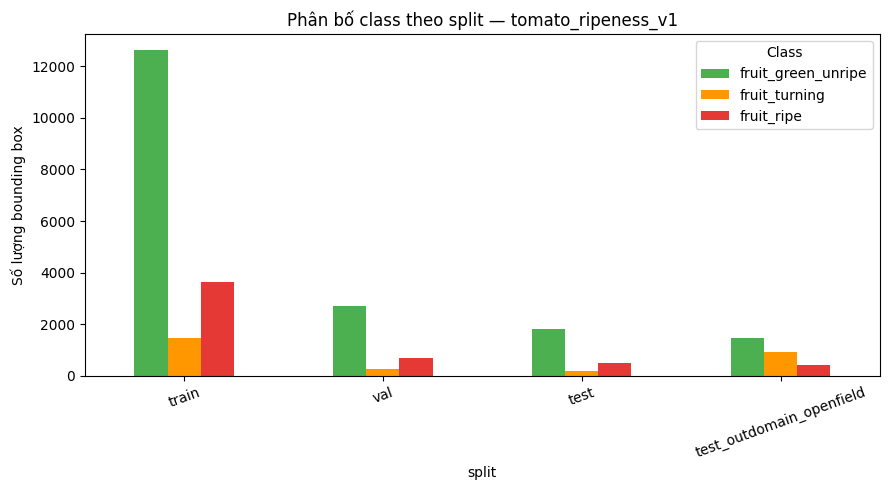

In [5]:
plot_df = overview_df.set_index("split")[TARGET_CLASSES]
ax = plot_df.plot(kind="bar", figsize=(9, 5), color=["#4caf50", "#ff9800", "#e53935"])
ax.set_ylabel("Số lượng bounding box")
ax.set_title("Phân bố class theo split — tomato_ripeness_v1")
ax.legend(title="Class")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("/kaggle/working/class_distribution_chart.png", dpi=100, bbox_inches="tight")
plt.show()
plt.close()

## Ảnh ví dụ (kèm bounding box)
Màu box: **xanh lá** = `fruit_green_unripe`, **cam** = `fruit_turning`, **đỏ** = `fruit_ripe`.

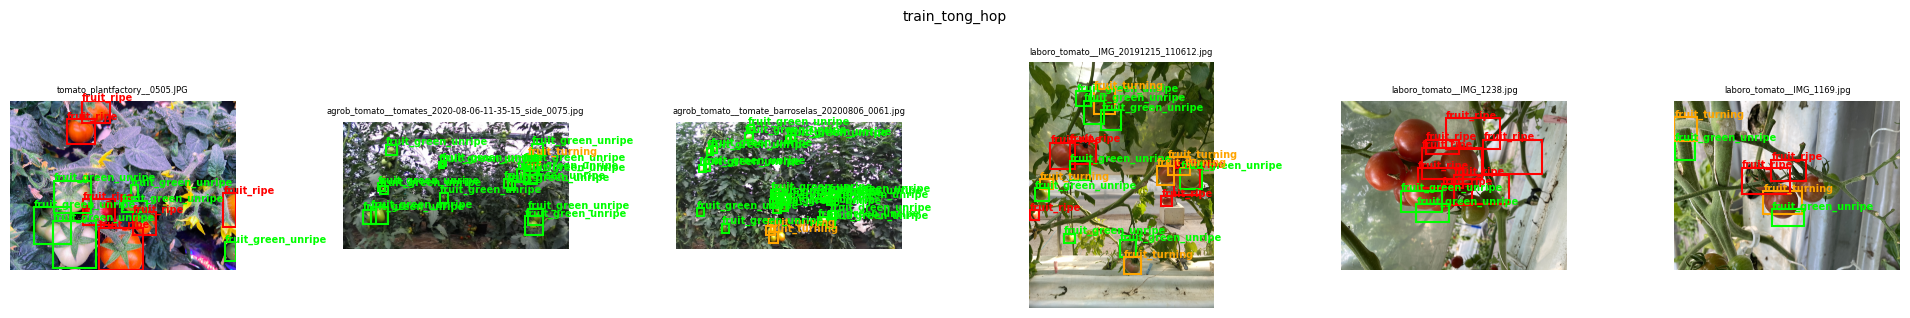

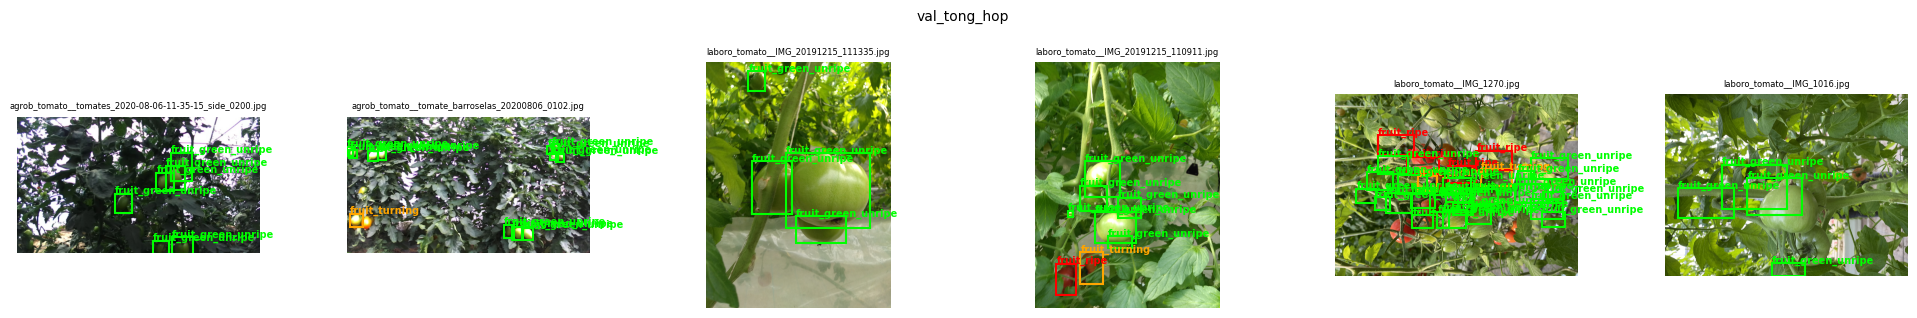

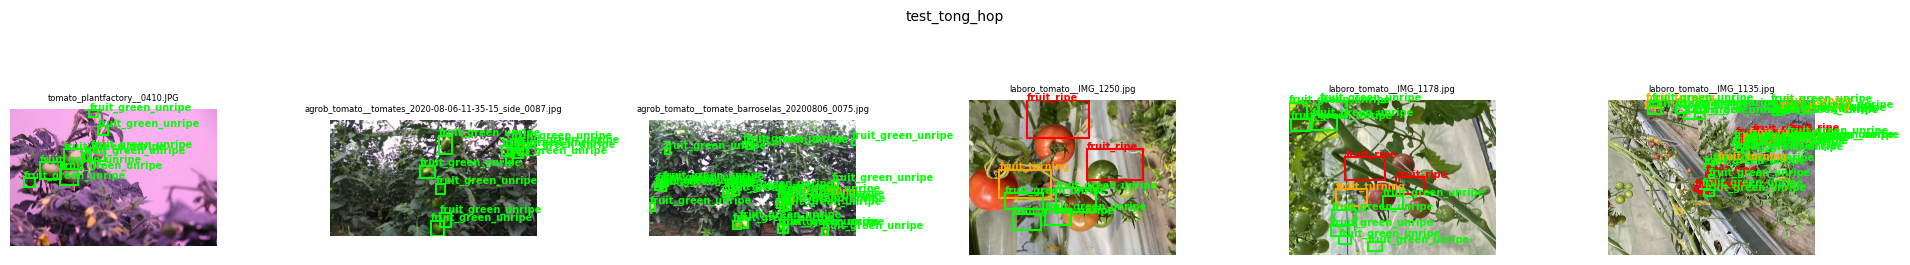

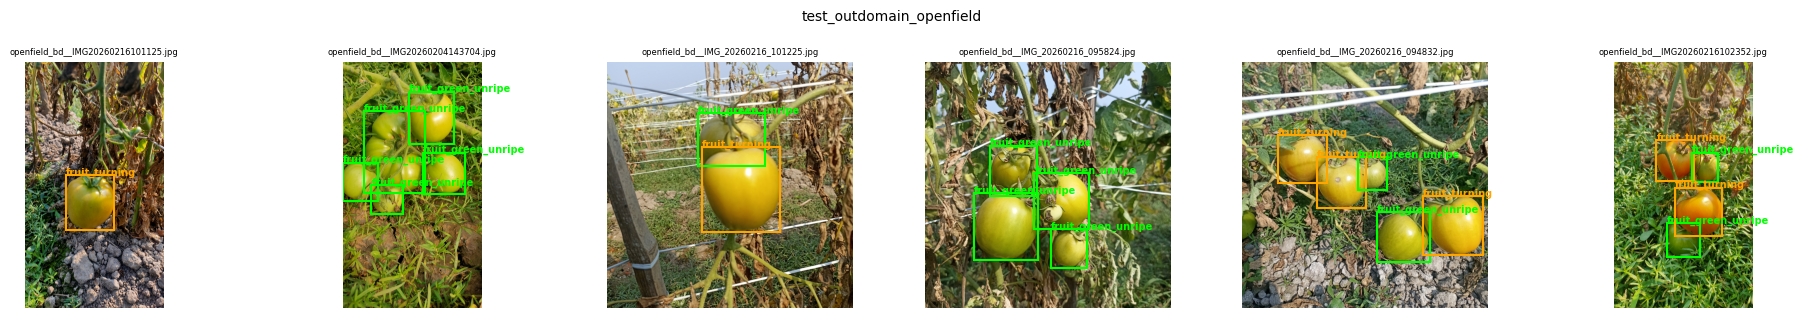

In [6]:
def show_samples(split, source_filter=None, n=6, title=""):
    images_dir = DATASET_ROOT / split / "images"
    labels_dir = DATASET_ROOT / split / "labels"
    all_imgs = sorted(images_dir.glob("*"))
    if source_filter:
        all_imgs = [p for p in all_imgs if p.name.startswith(source_filter + "__")]
    if not all_imgs:
        print(f"[{title}] Không có ảnh để hiển thị (source_filter={source_filter}).")
        return
    sample = random.Random(42).sample(all_imgs, min(n, len(all_imgs)))

    fig, axes = plt.subplots(1, len(sample), figsize=(3.2 * len(sample), 3.2))
    axes = [axes] if len(sample) == 1 else axes
    colors = ["lime", "orange", "red"]
    for ax, img_path in zip(axes, sample):
        img = Image.open(img_path)
        w, h = img.size
        ax.imshow(img)
        label_path = labels_dir / (img_path.stem + ".txt")
        if label_path.exists():
            for line in label_path.read_text().splitlines():
                if not line.strip():
                    continue
                cid, xc, yc, bw, bh = line.split()
                cid = int(cid)
                xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
                xmin, ymin = (xc - bw / 2) * w, (yc - bh / 2) * h
                rect = patches.Rectangle((xmin, ymin), bw * w, bh * h, linewidth=1.5,
                                          edgecolor=colors[cid], facecolor="none")
                ax.add_patch(rect)
                ax.text(xmin, max(ymin - 4, 0), TARGET_CLASSES[cid], color=colors[cid], fontsize=7, weight="bold")
        ax.set_title(img_path.name, fontsize=6)
        ax.axis("off")
    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/sample_{title}.png", dpi=80, bbox_inches="tight")
    plt.show()
    plt.close(fig)


show_samples("train", title="train_tong_hop")
show_samples("val", title="val_tong_hop")
show_samples("test", title="test_tong_hop")
show_samples("test_outdomain_openfield", title="test_outdomain_openfield")

## Báo cáo & manifest gốc (từ `01_build_tomato_ripeness_v1.ipynb`)
In lại nguyên văn nếu thư mục `manifests/` có trong input, để có đủ thông tin ở một chỗ (không cần mở lại notebook build).

In [7]:
if MANIFEST_ROOT:
    for fname in ["dataset_report.md", "licenses.md"]:
        fpath = MANIFEST_ROOT / fname
        if fpath.exists():
            print(f"===== {fname} =====")
            print(fpath.read_text(encoding="utf-8"))
            print()

    review_csv = MANIFEST_ROOT / "review_required.csv"
    rejected_csv = MANIFEST_ROOT / "rejected_images.csv"
    dup_csv = MANIFEST_ROOT / "duplicate_report.csv"
    if review_csv.exists():
        print(f"review_required.csv : {len(pd.read_csv(review_csv))} dòng (box bị loại khỏi label, cần xem thủ công)")
    if rejected_csv.exists():
        print(f"rejected_images.csv : {len(pd.read_csv(rejected_csv))} dòng (ảnh bị loại hoàn toàn khỏi dataset)")
    if dup_csv.exists():
        print(f"duplicate_report.csv: {len(pd.read_csv(dup_csv))} dòng (ảnh nằm trong nhóm trùng/near-duplicate)")
else:
    print("Không tìm thấy thư mục manifests/ trong input -> bỏ qua phần báo cáo gốc.")

===== dataset_report.md =====
# tomato_ripeness_v1 — Dataset Report
Sinh tự động bởi `01_build_tomato_ripeness_v1.ipynb` — 2026-08-05

## Convert theo nguồn
                     images_total  images_kept  boxes_kept  boxes_dropped_unmapped  boxes_review
laboro_tomato                 804          804        9777                       0             0
agrob_tomato                  449          435        5900                       0           184
tomato_plantfactory           520          520        8223                       0             0
openfield_bd                  604          604        2802                       0             0

## Phân bố ảnh theo split/nguồn
source                    agrob_tomato  laboro_tomato  openfield_bd  tomato_plantfactory
split                                                                                   
test                                44             81             0                   52
test_outdomain_openfield             0              0     

## Kết luận
Nếu số liệu ở trên hợp lý (không split nào `n_images = 0`, phân bố class không lệch bất thường, ảnh mẫu gắn đúng nhãn màu quả thật ở cả 4 split) thì `tomato_ripeness_v1` đã sẵn sàng làm input cho **`02_train_ripeness_baseline.ipynb`**.